<a href="https://colab.research.google.com/github/shahaayush573/32130965/blob/main/DataProcessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NorthStar Urban Mobility and Logistics  
## Python Data Processing and Analytics Notebook

This notebook supports the **Python data processing** part of the Databases and Analytics coursework.

It covers:

- loading the NorthStar dataset
- inspecting dataset structure
- checking missing values and duplicates
- cleaning zone names and date columns
- merging operational datasets
- analysing delivery performance, complaints, incidents, costs, and customer ratings
- creating visualisations for the final report
- exporting cleaned data for MongoDB/R work

## 1. Upload and extract dataset

In Google Colab, upload `northstar_dataset.zip` when asked.  
If the file is already in your Colab folder, the code will use it directly.

In [1]:
import os
import zipfile
from google.colab import files

zip_name = "northstar_dataset.zip"

if not os.path.exists(zip_name):
    print("Please upload northstar_dataset.zip")
    uploaded = files.upload()

extract_folder = "northstar_dataset_extracted"

with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("Dataset extracted successfully.")

for root, dirs, filenames in os.walk(extract_folder):
    for filename in filenames:
        print(os.path.join(root, filename))

Please upload northstar_dataset.zip


Saving northstar_dataset.zip to northstar_dataset.zip
Dataset extracted successfully.
northstar_dataset_extracted/northstar_dataset/deliveries.csv
northstar_dataset_extracted/northstar_dataset/orders.csv
northstar_dataset_extracted/northstar_dataset/hubs.csv
northstar_dataset_extracted/northstar_dataset/customers.csv
northstar_dataset_extracted/northstar_dataset/app_events.csv
northstar_dataset_extracted/northstar_dataset/data_dictionary.csv
northstar_dataset_extracted/northstar_dataset/complaints.csv
northstar_dataset_extracted/northstar_dataset/incidents.csv
northstar_dataset_extracted/northstar_dataset/vehicles.csv
northstar_dataset_extracted/northstar_dataset/README.txt
northstar_dataset_extracted/northstar_dataset/drivers.csv


## 2. Import Python libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load all CSV files

This section loads each CSV file into a Pandas DataFrame.

In [3]:
base_path = None

for root, dirs, filenames in os.walk(extract_folder):
    if "orders.csv" in filenames:
        base_path = root
        break

print("Dataset folder:", base_path)

orders = pd.read_csv(os.path.join(base_path, "orders.csv"))
deliveries = pd.read_csv(os.path.join(base_path, "deliveries.csv"))
customers = pd.read_csv(os.path.join(base_path, "customers.csv"))
complaints = pd.read_csv(os.path.join(base_path, "complaints.csv"))
app_events = pd.read_csv(os.path.join(base_path, "app_events.csv"))
drivers = pd.read_csv(os.path.join(base_path, "drivers.csv"))
vehicles = pd.read_csv(os.path.join(base_path, "vehicles.csv"))
incidents = pd.read_csv(os.path.join(base_path, "incidents.csv"))
hubs = pd.read_csv(os.path.join(base_path, "hubs.csv"))
data_dictionary = pd.read_csv(os.path.join(base_path, "data_dictionary.csv"))

datasets = {
    "orders": orders,
    "deliveries": deliveries,
    "customers": customers,
    "complaints": complaints,
    "app_events": app_events,
    "drivers": drivers,
    "vehicles": vehicles,
    "incidents": incidents,
    "hubs": hubs,
    "data_dictionary": data_dictionary
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} rows and {df.shape[1]} columns")

Dataset folder: northstar_dataset_extracted/northstar_dataset
orders: 1250 rows and 11 columns
deliveries: 950 rows and 13 columns
customers: 650 rows and 9 columns
complaints: 320 rows and 10 columns
app_events: 640 rows and 10 columns
drivers: 170 rows and 8 columns
vehicles: 120 rows and 8 columns
incidents: 280 rows and 7 columns
hubs: 8 rows and 5 columns
data_dictionary: 9 rows and 3 columns


### Screenshot 1 for report

Take a screenshot of the output above showing that all dataset files loaded successfully.

## 4. Display sample records

In [4]:
orders.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0


In [5]:
deliveries.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22


In [6]:
complaints.head()

,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
0,CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
1,CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
2,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
3,CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
4,CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18


## 5. Dataset structure and data types

In [7]:
for name, df in datasets.items():
    print("\n" + "="*60)
    print(name.upper())
    print("="*60)
    print(df.info())


ORDERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1250 non-null   object 
 1   customer_id            1250 non-null   object 
 2   service_type           1250 non-null   object 
 3   order_created_at       1250 non-null   object 
 4   promised_window_hours  1250 non-null   int64  
 5   pickup_zone            1250 non-null   object 
 6   dropoff_zone           1250 non-null   object 
 7   priority_level         1250 non-null   object 
 8   order_value            1250 non-null   float64
 9   booking_channel        1225 non-null   object 
 10  special_handling_flag  1250 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 107.6+ KB
None

DELIVERIES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 13 columns):
 #   Column            

## 6. Check missing values and duplicate rows

In [8]:
missing_summary = []

for name, df in datasets.items():
    missing_summary.append({
        "dataset": name,
        "rows": len(df),
        "columns": len(df.columns),
        "duplicate_rows": df.duplicated().sum(),
        "total_missing_values": df.isna().sum().sum()
    })

missing_summary_df = pd.DataFrame(missing_summary)
missing_summary_df

,dataset,rows,columns,duplicate_rows,total_missing_values
0,orders,1250,11,0,25
1,deliveries,950,13,0,33
2,customers,650,9,0,33
3,complaints,320,10,0,16
4,app_events,640,10,0,144
5,drivers,170,8,0,7
6,vehicles,120,8,0,4
7,incidents,280,7,0,17
8,hubs,8,5,0,0
9,data_dictionary,9,3,0,0


In [9]:
for name, df in datasets.items():
    print("\n" + "="*60)
    print(name.upper(), "missing values")
    print("="*60)
    print(df.isna().sum().sort_values(ascending=False))


ORDERS missing values
booking_channel          25
customer_id               0
order_id                  0
service_type              0
order_created_at          0
pickup_zone               0
promised_window_hours     0
dropoff_zone              0
priority_level            0
order_value               0
special_handling_flag     0
dtype: int64

DELIVERIES missing values
delivery_completed_at            19
customer_rating_post_delivery    14
driver_id                         0
order_id                          0
delivery_id                       0
hub_id                            0
vehicle_id                        0
delivery_status                   0
dispatch_time                     0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
fuel_or_charge_cost               0
dtype: int64

CUSTOMERS missing values
loyalty_score           20
preferred_channel       13
customer_id              0
age                      0
home_zone     

### Screenshot 2 for report

Take a screenshot of the missing-value summary.  
In the report, explain that checking missing values is important because poor data quality can create wrong business decisions.

## 7. Clean zone names

Some zones appear in different formats, for example `North`, `north`, `SOUTH`, and `AIRPORT`.  
This cleaning step makes zone values consistent.

In [10]:
def clean_zone(value):
    if pd.isna(value):
        return value
    value = str(value).strip().title()
    if value == "Airport":
        return "Airport"
    return value

zone_columns = {
    "orders": ["pickup_zone", "dropoff_zone"],
    "customers": ["home_zone"],
    "app_events": ["zone_context"],
    "drivers": ["base_zone"],
    "vehicles": ["assigned_zone"],
    "hubs": ["zone"]
}

for name, cols in zone_columns.items():
    df = datasets[name]
    for col in cols:
        if col in df.columns:
            df[col] = df[col].apply(clean_zone)

print("Zone names cleaned.")

print("Orders pickup zones:", sorted(orders["pickup_zone"].dropna().unique()))
print("Orders dropoff zones:", sorted(orders["dropoff_zone"].dropna().unique()))
print("Customer home zones:", sorted(customers["home_zone"].dropna().unique()))

Zone names cleaned.
Orders pickup zones: ['Airport', 'Central', 'Ctr', 'East', 'North', 'Riverside', 'South', 'West']
Orders dropoff zones: ['Airport', 'Central', 'Ctr', 'East', 'North', 'Riverside', 'South', 'West']
Customer home zones: ['Airport', 'Central', 'Ctr', 'East', 'North', 'Riverside', 'South', 'West']


## 8. Convert date and time columns

Date columns must be converted into datetime format before we calculate delivery time or analyse trends.

In [11]:
date_columns = {
    "orders": ["order_created_at"],
    "deliveries": ["dispatch_time", "delivery_completed_at"],
    "customers": ["signup_date"],
    "complaints": ["created_at"],
    "app_events": ["event_timestamp"],
    "vehicles": ["commission_date"],
    "incidents": ["reported_at"]
}

for name, cols in date_columns.items():
    df = datasets[name]
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

print("Date columns converted successfully.")

Date columns converted successfully.


## 9. Create useful calculated fields

This section calculates delivery duration and late/failed indicators.

In [12]:
deliveries["delivery_duration_hours"] = (
    deliveries["delivery_completed_at"] - deliveries["dispatch_time"]
).dt.total_seconds() / 3600

deliveries["is_failed"] = np.where(deliveries["delivery_status"].str.lower() == "failed", 1, 0)
deliveries["proof_missing_flag"] = deliveries["proof_of_completion_missing"].fillna(0).astype(int)

orders["order_month"] = orders["order_created_at"].dt.to_period("M").astype(str)
complaints["complaint_month"] = complaints["created_at"].dt.to_period("M").astype(str)
app_events["event_month"] = app_events["event_timestamp"].dt.to_period("M").astype(str)

deliveries[[
    "delivery_id",
    "order_id",
    "delivery_status",
    "delivery_duration_hours",
    "is_failed",
    "manual_route_override_count",
    "customer_rating_post_delivery"
]].head()

,delivery_id,order_id,delivery_status,delivery_duration_hours,is_failed,manual_route_override_count,customer_rating_post_delivery
0,DL00001,O00938,Failed,22.149973,1,1,3.07
1,DL00002,O00004,OnTime,-1.100000,0,1,5.00
2,DL00003,O00639,OnTime,1.108991,0,0,4.98
3,DL00004,O00313,Delayed,23.985584,0,0,4.18
4,DL00005,O00844,OnTime,4.042814,0,1,4.18


## 10. Merge orders, deliveries, customers, drivers, vehicles, and hubs

This creates one integrated operational dataset.  
This is important because the NorthStar case study says the company struggles because different data sources are not connected.

In [13]:
ops = deliveries.merge(
    orders,
    on="order_id",
    how="left"
).merge(
    customers,
    on="customer_id",
    how="left"
).merge(
    drivers,
    on="driver_id",
    how="left"
).merge(
    vehicles,
    on="vehicle_id",
    how="left"
).merge(
    hubs,
    on="hub_id",
    how="left",
    suffixes=("", "_hub")
)

print("Integrated dataset shape:", ops.shape)
ops.head()

Integrated dataset shape: (950, 53)


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,delivery_duration_hours,is_failed,proof_missing_flag,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag,order_month,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status,base_zone,employment_type,years_experience,training_score,driver_rating,shift_preference,active_flag,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version,hub_name,zone,hub_type,capacity_score
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05,22.149973,1,0,C0567,Business,2024-06-18 09:48:00,6,Central,Central,Medium,151.14,Web,0,2024-06,74,East,Consumer,2024-02-18 04:31:00,79.7,64.9,App,Active,Airport,PartTime,13,88.9,4.75,Morning,1,EV,Central,2024-06-09 16:18:00,78.4,29849,Active,v2.2,Central Core,Central,Control,88
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41,-1.100000,0,0,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,1,2025-01,50,North,Consumer,2025-04-21 07:28:00,53.6,80.4,Partner API,Active,Ctr,PartTime,11,69.2,4.61,Evening,1,Diesel,Airport,2025-09-17 08:52:00,68.6,78468,Active,v2.2,South Link,South,Dispatch,78
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51,1.108991,0,0,C0480,Medical,2025-06-02 19:12:00,2,Central,North,Medium,141.93,Web,0,2025-06,26,North,Enterprise,2025-03-02 00:55:00,67.6,49.6,App,Dormant,Central,FullTime,8,78.8,4.38,Flexible,1,Diesel,East,2025-12-09 16:47:00,55.9,15278,Active,v2.2,South Link,South,Dispatch,78
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62,23.985584,0,0,C0616,Medical,2024-03-08 20:58:00,24,South,North,Low,11.11,App,0,2024-03,49,Riverside,Consumer,2024-11-30 06:56:00,65.9,78.2,Phone,Active,Central,FullTime,4,58.2,4.19,Morning,1,Hybrid,East,2025-06-05 13:40:00,83.3,85635,Active,v2.1,South Link,South,Dispatch,78
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22,4.042814,0,0,C0276,Medical,2025-09-21 09:29:00,6,Riverside,Riverside,High,76.02,App,0,2025-09,47,South,Consumer,2024-11-15 02:59:00,66.9,76.6,App,Active,South,FullTime,10,70.6,4.33,Morning,1,EV,Riverside,2025-05-24 09:58:00,94.2,210683,InRepair,v2.0,North Exchange,North,Dispatch,82


### Screenshot 3 for report

Take a screenshot showing the integrated dataset output.  
This proves that you connected separate operational systems together.

## 11. Delivery status analysis

In [14]:
delivery_status_count = deliveries["delivery_status"].value_counts().reset_index()
delivery_status_count.columns = ["delivery_status", "count"]
delivery_status_count

,delivery_status,count
0,OnTime,616
1,Delayed,202
2,Failed,132


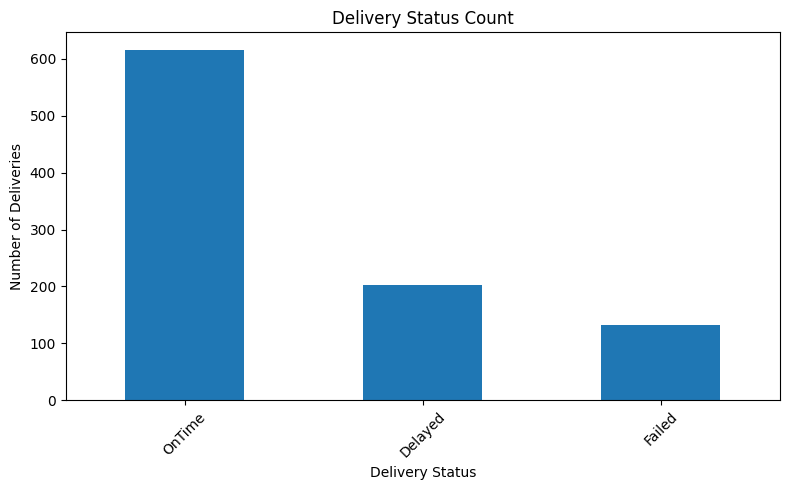

In [15]:
plt.figure(figsize=(8, 5))
deliveries["delivery_status"].value_counts().plot(kind="bar")
plt.title("Delivery Status Count")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Deliveries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Report interpretation

This chart should be used to explain how many deliveries were completed on time, delayed, or failed.  
A high number of failed or delayed deliveries would support the case study problem that service reliability is weak.

## 12. Delivery performance by zone

In [16]:
zone_performance = ops.groupby("dropoff_zone").agg(
    total_deliveries=("delivery_id", "count"),
    failed_deliveries=("is_failed", "sum"),
    average_rating=("customer_rating_post_delivery", "mean"),
    average_route_overrides=("manual_route_override_count", "mean"),
    average_cost=("fuel_or_charge_cost", "mean")
).reset_index()

zone_performance["failure_rate_pct"] = (
    zone_performance["failed_deliveries"] / zone_performance["total_deliveries"] * 100
).round(2)

zone_performance = zone_performance.sort_values("failure_rate_pct", ascending=False)
zone_performance

,dropoff_zone,total_deliveries,failed_deliveries,average_rating,average_route_overrides,average_cost,failure_rate_pct
1,Central,98,18,3.782292,1.081633,12.660408,18.37
4,North,145,25,3.830979,0.979310,13.337586,17.24
2,Ctr,49,7,3.734694,0.836735,12.659184,14.29
6,South,130,18,3.847187,0.923077,12.358846,13.85
5,Riverside,141,19,3.957357,0.950355,13.207092,13.48
3,East,118,14,3.857778,0.974576,12.916441,11.86
7,West,146,17,3.923077,0.952055,13.156438,11.64
0,Airport,123,14,3.871500,1.008130,12.117317,11.38


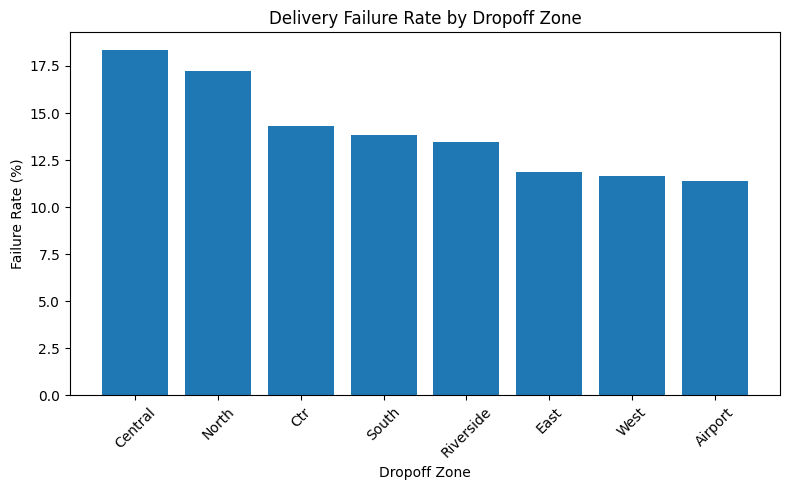

In [17]:
plt.figure(figsize=(8, 5))
plt.bar(zone_performance["dropoff_zone"], zone_performance["failure_rate_pct"])
plt.title("Delivery Failure Rate by Dropoff Zone")
plt.xlabel("Dropoff Zone")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Screenshot 4 for report

Take a screenshot of the table and chart above.  
In the report, explain which zone has the highest failure rate and why management should investigate it.

## 13. Customer complaints analysis

In [18]:
complaint_type_summary = complaints.groupby("complaint_type").agg(
    number_of_complaints=("complaint_id", "count"),
    average_resolution_days=("resolution_days", "mean"),
    average_compensation=("compensation_amount", "mean")
).reset_index().sort_values("number_of_complaints", ascending=False)

complaint_type_summary

,complaint_type,number_of_complaints,average_resolution_days,average_compensation
3,Delay,101,7.257426,18.051489
5,MissedPickup,64,7.640625,22.593651
0,AppIssue,53,8.603774,19.614400
4,DriverBehaviour,51,8.156863,21.153478
6,SupportExperience,20,7.450000,17.125000
1,Billing,16,7.750000,23.871250
2,Damage,15,11.333333,23.982000


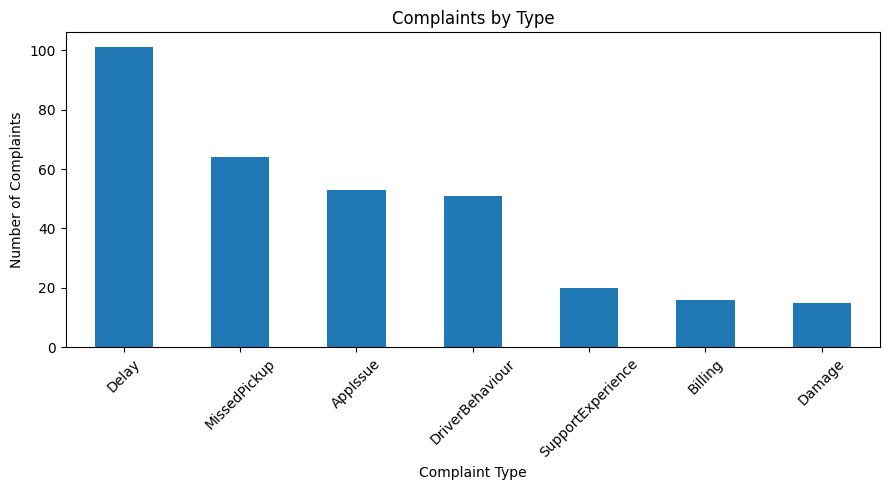

In [19]:
plt.figure(figsize=(9, 5))
complaints["complaint_type"].value_counts().plot(kind="bar")
plt.title("Complaints by Type")
plt.xlabel("Complaint Type")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

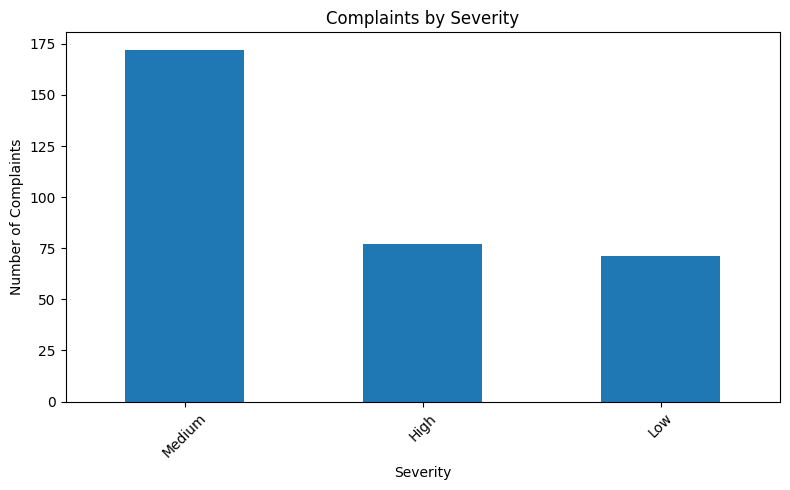

In [20]:
plt.figure(figsize=(8, 5))
complaints["severity"].value_counts().plot(kind="bar")
plt.title("Complaints by Severity")
plt.xlabel("Severity")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Report interpretation

Use this section to discuss the most common complaint types and whether serious complaints take longer to resolve or cost more compensation.

## 14. Link complaints with orders and deliveries

In [21]:
complaints_ops = complaints.merge(
    orders,
    on=["order_id", "customer_id"],
    how="left"
).merge(
    deliveries,
    on="order_id",
    how="left"
)

print("Complaints linked with orders and deliveries:", complaints_ops.shape)
complaints_ops.head()

Complaints linked with orders and deliveries: (320, 36)


,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount,complaint_month,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag,order_month,delivery_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,delivery_duration_hours,is_failed,proof_missing_flag
0,CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99,2025-03,Passenger,2025-03-26 02:36:00,12,East,Riverside,Medium,27.90,Phone,0,2025-03,DL00426,D150,V053,H05,2025-03-26 04:54:00,2025-03-26 14:37:28.110426,OnTime,12.88,1.0,0.0,4.57,19.14,9.724475,0.0,0.0
1,CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64,2024-11,Passenger,2024-10-26 10:05:00,12,Riverside,North,Medium,52.85,App,1,2024-10,DL00790,D170,V039,H08,2024-10-26 12:51:00,2024-10-27 03:56:55.676864,Delayed,12.25,0.0,1.0,3.68,5.21,15.098799,0.0,1.0
2,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41,2024-01,Medical,2024-01-01 15:47:00,4,Ctr,Central,Low,12.58,Web,0,2024-01,DL00890,D103,V020,H03,2024-01-01 16:28:00,2024-01-02 02:33:42.522654,Delayed,9.61,0.0,0.0,3.51,9.44,10.095145,0.0,0.0
3,CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44,2025-01,Retail,2025-01-05 13:07:00,2,Airport,Riverside,Critical,59.17,App,0,2025-01,DL00200,D160,V106,H06,2025-01-05 13:23:00,2025-01-05 14:10:14.767186,OnTime,31.46,2.0,0.0,4.38,16.38,0.787435,0.0,0.0
4,CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18,2024-08,Business,2024-08-20 05:56:00,12,North,Airport,Low,105.88,Web,1,2024-08,DL00693,D137,V063,H03,2024-08-20 06:10:00,2024-08-20 23:47:35.347105,Delayed,13.63,0.0,0.0,2.62,11.31,17.626485,0.0,0.0


In [22]:
complaint_delivery_status = complaints_ops.groupby(["complaint_type", "delivery_status"]).size().reset_index(name="count")
complaint_delivery_status.sort_values("count", ascending=False).head(20)

,complaint_type,delivery_status,count
11,Delay,OnTime,44
14,DriverBehaviour,OnTime,29
17,MissedPickup,OnTime,25
2,AppIssue,OnTime,25
9,Delay,Delayed,19
15,MissedPickup,Delayed,11
20,SupportExperience,OnTime,11
10,Delay,Failed,10
8,Damage,OnTime,8
16,MissedPickup,Failed,8


## 15. Route override analysis

Manual route overrides are important because the case study says drivers sometimes change planned routes.  
This may happen because of real road problems, poor planning, or performance pressure.

In [23]:
override_summary = ops.groupby("dropoff_zone").agg(
    average_route_overrides=("manual_route_override_count", "mean"),
    average_rating=("customer_rating_post_delivery", "mean"),
    failure_rate=("is_failed", "mean")
).reset_index()

override_summary["failure_rate_pct"] = (override_summary["failure_rate"] * 100).round(2)
override_summary.sort_values("average_route_overrides", ascending=False)

,dropoff_zone,average_route_overrides,average_rating,failure_rate,failure_rate_pct
1,Central,1.081633,3.782292,0.183673,18.37
0,Airport,1.008130,3.871500,0.113821,11.38
4,North,0.979310,3.830979,0.172414,17.24
3,East,0.974576,3.857778,0.118644,11.86
7,West,0.952055,3.923077,0.116438,11.64
5,Riverside,0.950355,3.957357,0.134752,13.48
6,South,0.923077,3.847187,0.138462,13.85
2,Ctr,0.836735,3.734694,0.142857,14.29


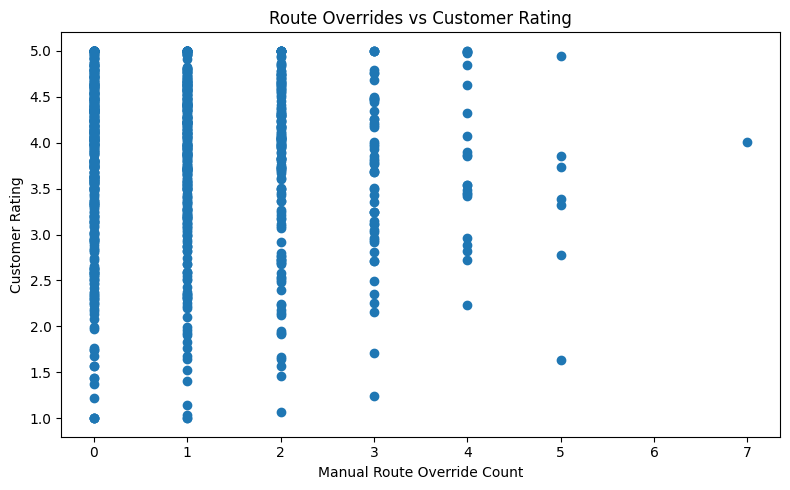

In [24]:
plt.figure(figsize=(8, 5))
plt.scatter(ops["manual_route_override_count"], ops["customer_rating_post_delivery"])
plt.title("Route Overrides vs Customer Rating")
plt.xlabel("Manual Route Override Count")
plt.ylabel("Customer Rating")
plt.tight_layout()
plt.show()

In [25]:
correlation = ops[["manual_route_override_count", "customer_rating_post_delivery", "fuel_or_charge_cost", "delivery_duration_hours"]].corr()
correlation

,manual_route_override_count,customer_rating_post_delivery,fuel_or_charge_cost,delivery_duration_hours
manual_route_override_count,1.000000,-0.059903,0.098690,-0.013711
customer_rating_post_delivery,-0.059903,1.000000,-0.059062,-0.305731
fuel_or_charge_cost,0.098690,-0.059062,1.000000,0.049378
delivery_duration_hours,-0.013711,-0.305731,0.049378,1.000000


### Report interpretation

If route overrides are linked with lower customer ratings or higher costs, NorthStar should review route planning quality and driver instructions.

## 16. Hub performance analysis

In [26]:
hub_performance = ops.groupby(["hub_id", "hub_name", "zone"]).agg(
    total_deliveries=("delivery_id", "count"),
    failed_deliveries=("is_failed", "sum"),
    average_rating=("customer_rating_post_delivery", "mean"),
    average_cost=("fuel_or_charge_cost", "mean"),
    average_route_overrides=("manual_route_override_count", "mean"),
    capacity_score=("capacity_score", "mean")
).reset_index()

hub_performance["failure_rate_pct"] = (
    hub_performance["failed_deliveries"] / hub_performance["total_deliveries"] * 100
).round(2)

hub_performance.sort_values("failure_rate_pct", ascending=False)

,hub_id,hub_name,zone,total_deliveries,failed_deliveries,average_rating,average_cost,average_route_overrides,capacity_score,failure_rate_pct
7,H08,Midtown Relay,Central,128,26,3.884560,11.708203,1.109375,63.0,20.31
4,H05,Central Core,Central,115,23,3.669558,13.686000,0.947826,88.0,20.00
5,H06,Airport Hub,Airport,104,15,3.882136,13.319231,0.913462,71.0,14.42
3,H04,West Gate,West,127,16,3.915476,13.167008,0.874016,69.0,12.60
0,H01,North Exchange,North,136,17,3.840593,12.755809,1.029412,82.0,12.50
6,H07,Riverside Hub,Riverside,115,14,3.881858,12.922087,1.052174,66.0,12.17
1,H02,South Link,South,106,10,3.950952,12.565000,0.915094,78.0,9.43
2,H03,East Dock,East,119,11,3.895862,12.744202,0.890756,74.0,9.24


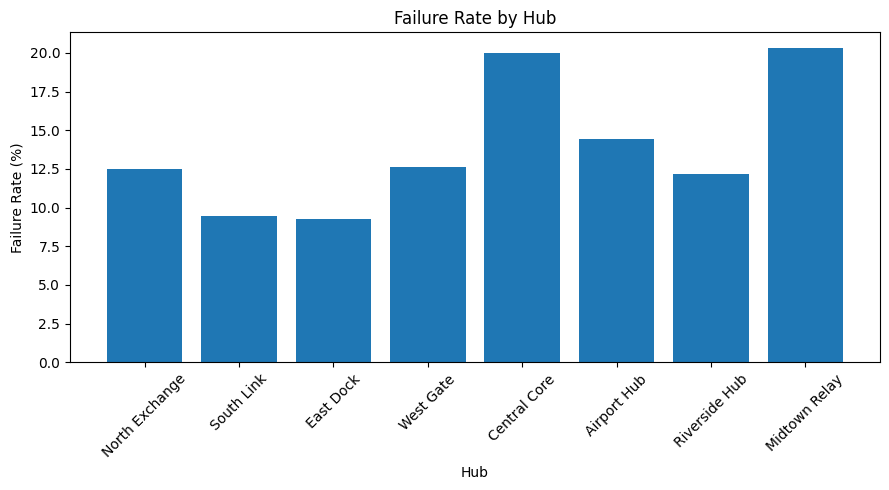

In [27]:
plt.figure(figsize=(9, 5))
plt.bar(hub_performance["hub_name"], hub_performance["failure_rate_pct"])
plt.title("Failure Rate by Hub")
plt.xlabel("Hub")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 17. Vehicle maintenance and battery analysis

In [28]:
vehicle_summary = vehicles.groupby(["vehicle_type", "maintenance_status"]).agg(
    vehicle_count=("vehicle_id", "count"),
    average_battery_health=("battery_health_pct", "mean"),
    average_odometer=("odometer_km", "mean")
).reset_index()

vehicle_summary

,vehicle_type,maintenance_status,vehicle_count,average_battery_health,average_odometer
0,CargoVan,Active,14,76.192857,105834.500000
1,CargoVan,InRepair,12,71.475000,112507.250000
2,CargoVan,Scheduled,4,69.275000,138535.500000
3,Diesel,Active,10,65.420000,80712.800000
4,Diesel,InRepair,7,75.614286,91508.285714
5,Diesel,Scheduled,2,78.600000,124911.500000
6,EV,Active,29,83.125926,120892.344828
7,EV,InRepair,8,78.550000,134185.500000
8,EV,Scheduled,6,82.383333,140850.333333
9,Hybrid,Active,14,71.858333,121092.000000


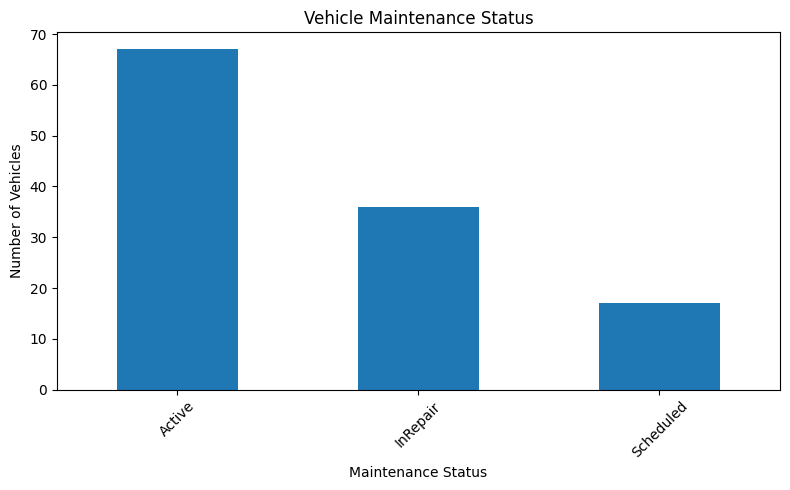

In [29]:
plt.figure(figsize=(8, 5))
vehicles["maintenance_status"].value_counts().plot(kind="bar")
plt.title("Vehicle Maintenance Status")
plt.xlabel("Maintenance Status")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

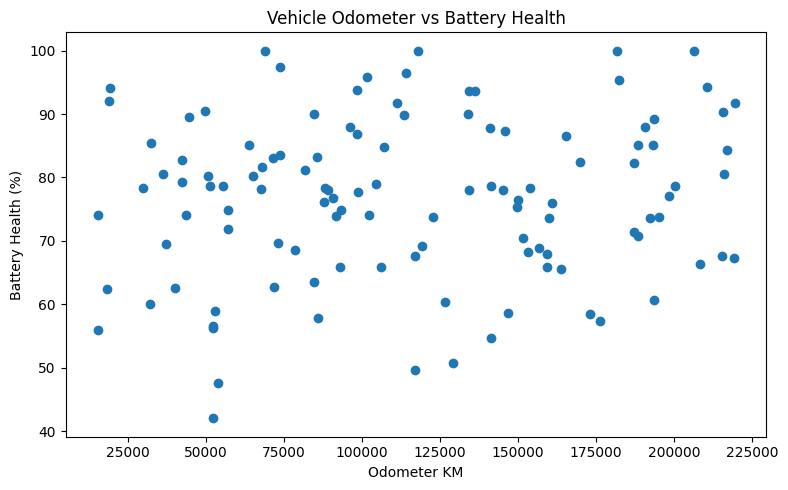

In [30]:
plt.figure(figsize=(8, 5))
plt.scatter(vehicles["odometer_km"], vehicles["battery_health_pct"])
plt.title("Vehicle Odometer vs Battery Health")
plt.xlabel("Odometer KM")
plt.ylabel("Battery Health (%)")
plt.tight_layout()
plt.show()

## 18. Incident analysis

In [31]:
incident_summary = incidents.groupby(["incident_type", "severity"]).agg(
    incident_count=("incident_id", "count"),
    average_resolved_hours=("resolved_hours", "mean")
).reset_index().sort_values("incident_count", ascending=False)

incident_summary.head(20)

,incident_type,severity,incident_count,average_resolved_hours
7,BatteryAlert,Medium,18,11.112500
18,RouteDeviation,Low,17,16.017647
31,VehicleFault,Medium,16,5.837500
3,AppSyncError,Medium,15,11.907692
15,ProofMissing,Medium,15,11.041667
10,CustomerNoShow,Low,15,14.140000
11,CustomerNoShow,Medium,13,14.061538
14,ProofMissing,Low,13,14.891667
27,TemperatureIssue,Medium,13,16.323077
17,RouteDeviation,High,12,13.058333


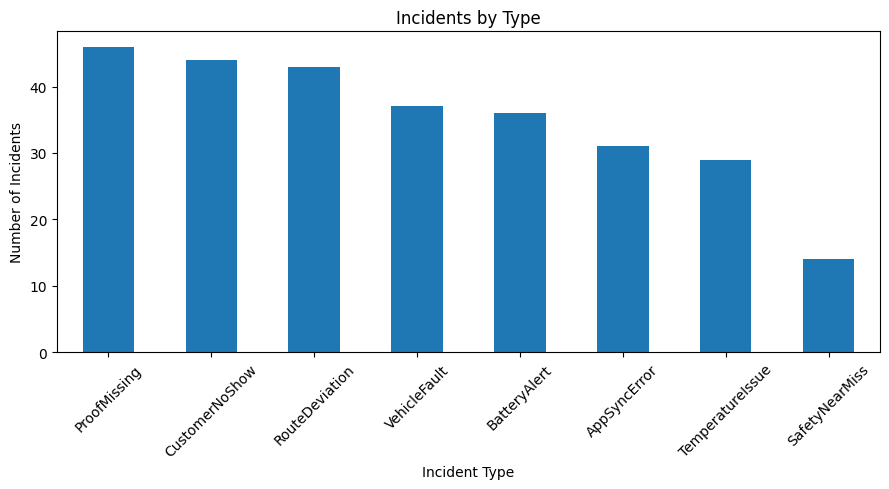

In [32]:
plt.figure(figsize=(9, 5))
incidents["incident_type"].value_counts().plot(kind="bar")
plt.title("Incidents by Type")
plt.xlabel("Incident Type")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 19. App events and platform reliability

In [33]:
app_event_summary = app_events.groupby("event_type").agg(
    event_count=("event_id", "count"),
    average_api_latency_ms=("api_latency_ms", "mean"),
    success_rate=("success_flag", "mean")
).reset_index()

app_event_summary["success_rate_pct"] = (app_event_summary["success_rate"] * 100).round(2)
app_event_summary.sort_values("average_api_latency_ms", ascending=False)

,event_type,event_count,average_api_latency_ms,success_rate,success_rate_pct
3,delivery_instruction_update,75,496.293333,1.000000,100.00
2,chat_opened,88,478.329545,1.000000,100.00
1,chat_escalated,38,478.131579,0.500000,50.00
5,payment_retry,69,472.681159,0.724638,72.46
7,track_order,138,460.710145,1.000000,100.00
6,search_route,99,456.505051,1.000000,100.00
4,eta_refresh,105,452.152381,1.000000,100.00
0,cancel_attempt,28,417.142857,1.000000,100.00


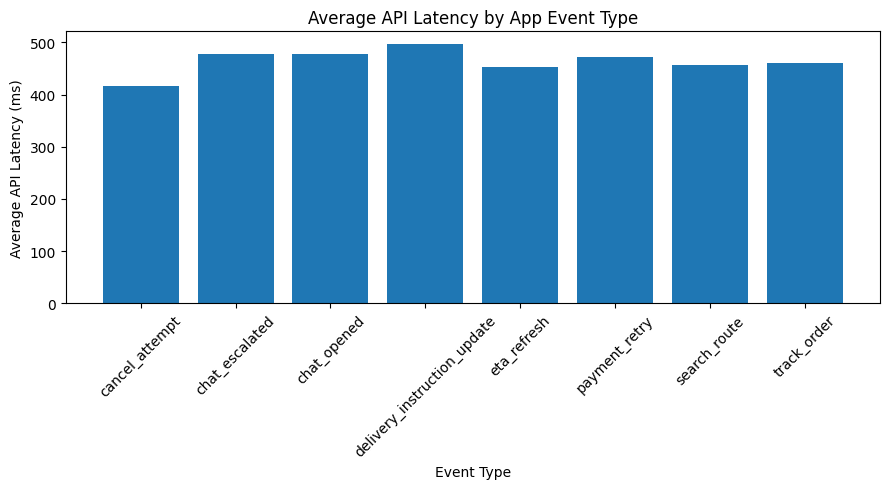

In [34]:
plt.figure(figsize=(9, 5))
plt.bar(app_event_summary["event_type"], app_event_summary["average_api_latency_ms"])
plt.title("Average API Latency by App Event Type")
plt.xlabel("Event Type")
plt.ylabel("Average API Latency (ms)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 20. Cost analysis

In [35]:
cost_by_service = ops.groupby("service_type").agg(
    total_orders=("order_id", "count"),
    total_order_value=("order_value", "sum"),
    average_order_value=("order_value", "mean"),
    average_delivery_cost=("fuel_or_charge_cost", "mean"),
    average_rating=("customer_rating_post_delivery", "mean"),
    failure_rate=("is_failed", "mean")
).reset_index()

cost_by_service["failure_rate_pct"] = (cost_by_service["failure_rate"] * 100).round(2)
cost_by_service

,service_type,total_orders,total_order_value,average_order_value,average_delivery_cost,average_rating,failure_rate,failure_rate_pct
0,Business,126,12279.23,97.454206,13.142143,3.847280,0.198413,19.84
1,Medical,108,9344.88,86.526667,12.772963,3.837685,0.148148,14.81
2,Parcel,230,20735.44,90.154087,13.082652,3.901637,0.108696,10.87
3,Passenger,262,25463.36,97.188397,12.399084,3.845253,0.145038,14.50
4,Retail,224,19444.86,86.807411,12.974420,3.872545,0.125000,12.50


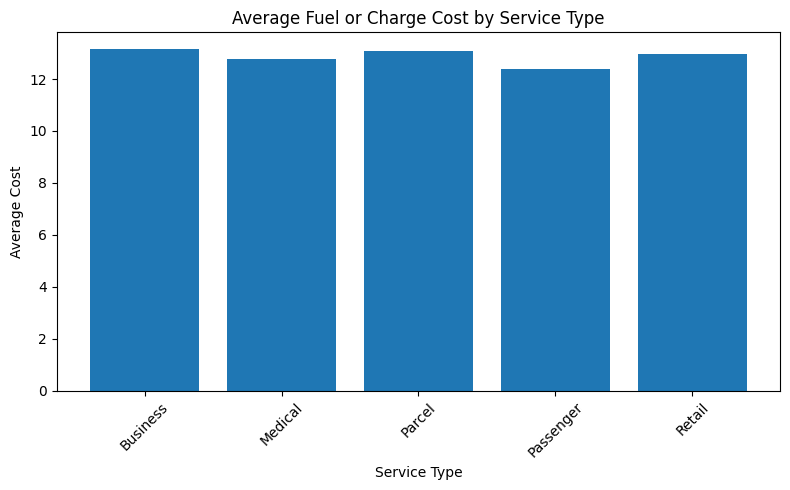

In [36]:
plt.figure(figsize=(8, 5))
plt.bar(cost_by_service["service_type"], cost_by_service["average_delivery_cost"])
plt.title("Average Fuel or Charge Cost by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Average Cost")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 21. Main findings summary table

Use this table in your report to write the findings section.

In [37]:
findings = []

worst_zone = zone_performance.iloc[0]
findings.append({
    "area": "Zone performance",
    "finding": f"{worst_zone['dropoff_zone']} has the highest delivery failure rate at {worst_zone['failure_rate_pct']}%.",
    "business_meaning": "NorthStar should investigate route planning, driver availability, and operational issues in this zone."
})

top_complaint = complaint_type_summary.iloc[0]
findings.append({
    "area": "Complaints",
    "finding": f"The most common complaint type is {top_complaint['complaint_type']} with {top_complaint['number_of_complaints']} complaints.",
    "business_meaning": "This shows the strongest source of customer dissatisfaction."
})

worst_hub = hub_performance.sort_values("failure_rate_pct", ascending=False).iloc[0]
findings.append({
    "area": "Hub performance",
    "finding": f"{worst_hub['hub_name']} has the highest hub failure rate at {worst_hub['failure_rate_pct']}%.",
    "business_meaning": "The hub may need operational review, better staffing, or route redesign."
})

top_incident = incidents["incident_type"].value_counts().idxmax()
findings.append({
    "area": "Incidents",
    "finding": f"The most common incident type is {top_incident}.",
    "business_meaning": "Incident patterns should be linked with vehicle and delivery data to prevent repeated service failures."
})

findings_df = pd.DataFrame(findings)
findings_df

,area,finding,business_meaning
0,Zone performance,Central has the highest delivery failure rate ...,"NorthStar should investigate route planning, d..."
1,Complaints,The most common complaint type is Delay with 1...,This shows the strongest source of customer di...
2,Hub performance,Midtown Relay has the highest hub failure rate...,"The hub may need operational review, better st..."
3,Incidents,The most common incident type is ProofMissing.,Incident patterns should be linked with vehicl...


## 22. Export cleaned data

These files can be used later for R, SQL, MongoDB import, and GitHub submission.

In [38]:
output_folder = "northstar_cleaned_outputs"
os.makedirs(output_folder, exist_ok=True)

orders.to_csv(os.path.join(output_folder, "cleaned_orders.csv"), index=False)
deliveries.to_csv(os.path.join(output_folder, "cleaned_deliveries.csv"), index=False)
customers.to_csv(os.path.join(output_folder, "cleaned_customers.csv"), index=False)
complaints.to_csv(os.path.join(output_folder, "cleaned_complaints.csv"), index=False)
app_events.to_csv(os.path.join(output_folder, "cleaned_app_events.csv"), index=False)
drivers.to_csv(os.path.join(output_folder, "cleaned_drivers.csv"), index=False)
vehicles.to_csv(os.path.join(output_folder, "cleaned_vehicles.csv"), index=False)
incidents.to_csv(os.path.join(output_folder, "cleaned_incidents.csv"), index=False)
hubs.to_csv(os.path.join(output_folder, "cleaned_hubs.csv"), index=False)
ops.to_csv(os.path.join(output_folder, "integrated_operations_dataset.csv"), index=False)
findings_df.to_csv(os.path.join(output_folder, "main_findings_summary.csv"), index=False)

print("Cleaned files exported to:", output_folder)
print(os.listdir(output_folder))

Cleaned files exported to: northstar_cleaned_outputs
['cleaned_app_events.csv', 'cleaned_vehicles.csv', 'cleaned_drivers.csv', 'cleaned_customers.csv', 'cleaned_complaints.csv', 'main_findings_summary.csv', 'cleaned_orders.csv', 'integrated_operations_dataset.csv', 'cleaned_incidents.csv', 'cleaned_hubs.csv', 'cleaned_deliveries.csv']


In [39]:
import shutil

shutil.make_archive("northstar_cleaned_outputs", "zip", output_folder)
files.download("northstar_cleaned_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>